In [2]:
import os
os.chdir('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ppg_preprocess import generate_synthetic_ppg, add_noise, process_ppg_with_biosppy, process_ppg,is_ppg_signal 
from scipy.signal import butter, filtfilt
from ppg_preprocess import butter_bandpass, bandpass_filter,plot_fft,overlapping_windows,calculate_snr_around_peaks
from ppg_preprocess import *
import biosppy
import neurokit2 as nk
import scipy.stats as stats
import seaborn as sns
import matplotlib
print(matplotlib.__version__)

3.5.3


In [3]:
# Function to create scatter plots
def create_scatter_plot(df, feature, save_path):
    plt.figure(figsize=(8, 6))
    
    # Create scatter plot with x-axis as the feature, y-axis as index, and colors based on sleep_label
    sns.scatterplot(x=df.index, y=df[feature], hue=df['sleep_label'], palette='coolwarm', style=df['sleep_label'], markers=['o', 's'], legend='full')

    plt.title(f'Scatter Plot of {feature} with Sleep/Awake Labels')
    plt.xlabel('Index')
    plt.ylabel(f'{feature}')
    plt.legend(title='Sleep Label', loc='upper right')
    #plt.savefig(save_path)
    #plt.close()
    plt.show()
    
# Function to create distribution plots
def create_distribution_plot(df, feature, save_path):
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=feature, hue='sleep_label', kde=True, palette='coolwarm')
    plt.title(f'Distribution of {feature} for Sleep and Awake')
    plt.xlabel(f'{feature}')
    plt.ylabel('Density')
    #plt.savefig(save_path)
    plt.show()
    #plt.close()

# Function to create bar plot of medians
def create_median_bar_plot(df, feature_list, save_path):
    median_df = df.groupby('sleep_label')[feature_list].median().reset_index()
    median_df = pd.melt(median_df, id_vars='sleep_label', var_name='Feature', value_name='Median')
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Feature', y='Median', hue='sleep_label', data=median_df, palette='coolwarm')
    plt.title(f'Median of Features for Sleep and Awake')
    plt.xlabel('Feature')
    plt.ylabel('Median Value')
    #plt.savefig(save_path)
    plt.show()
    #plt.close()


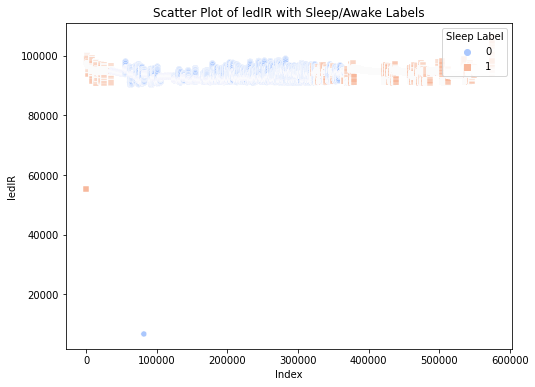

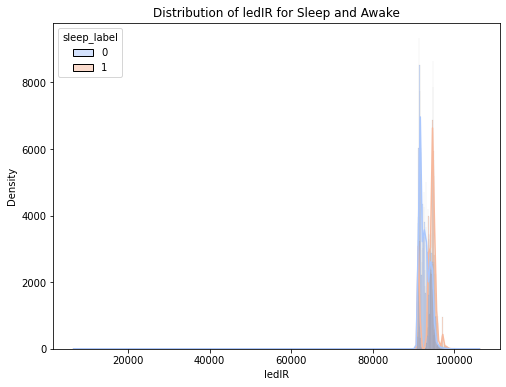

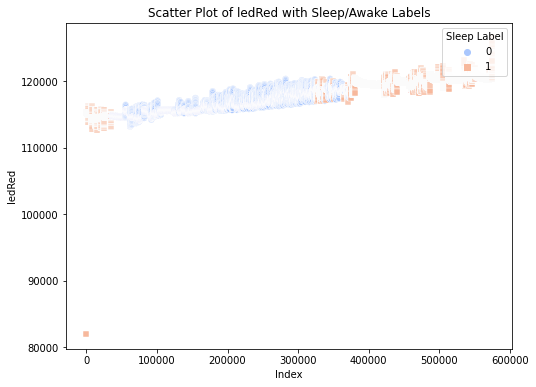

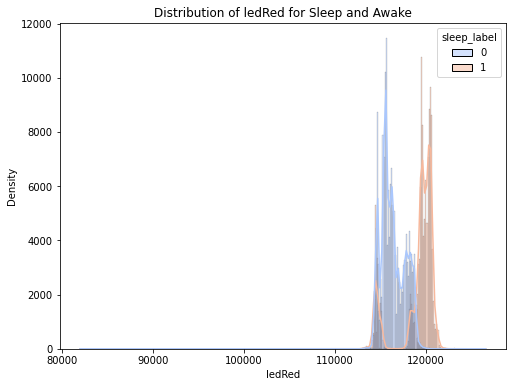

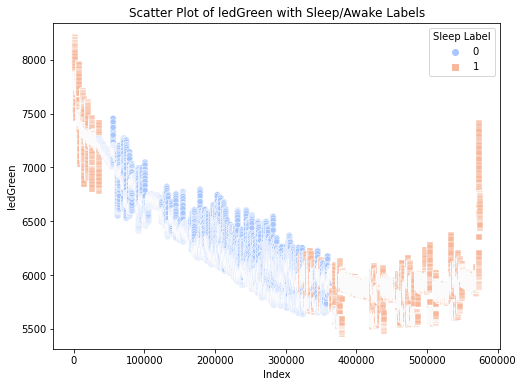

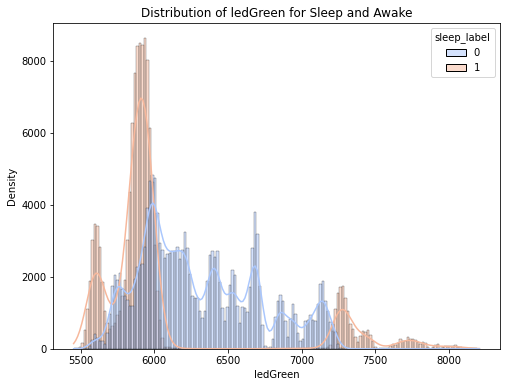

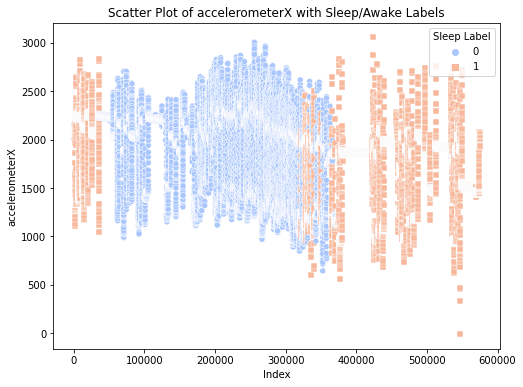

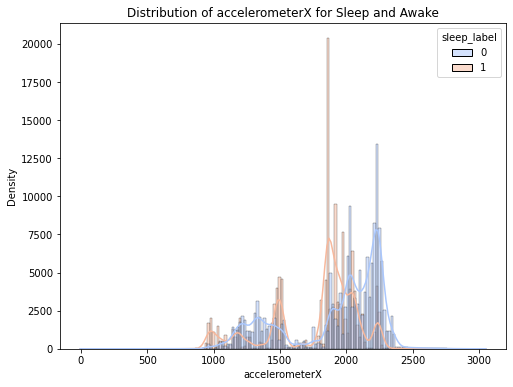

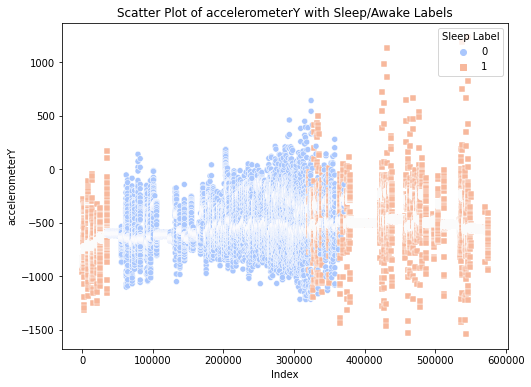

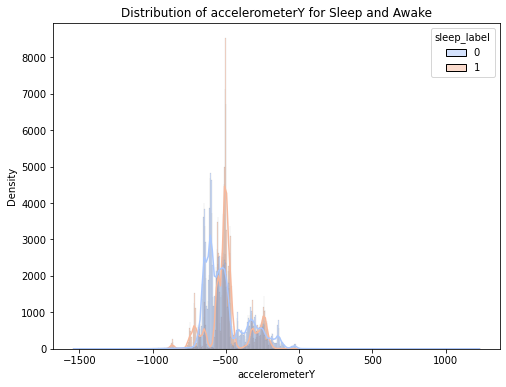

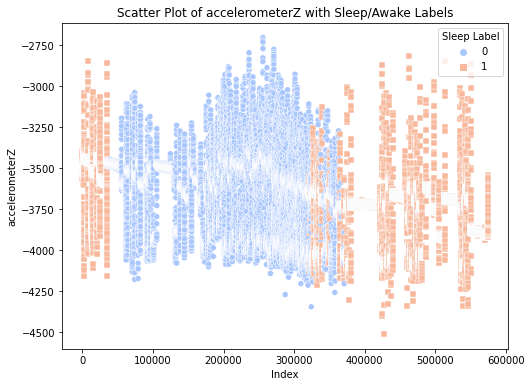

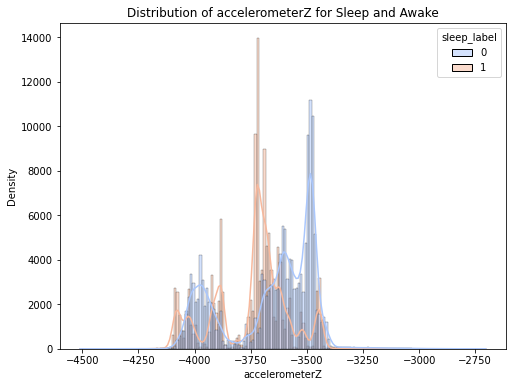

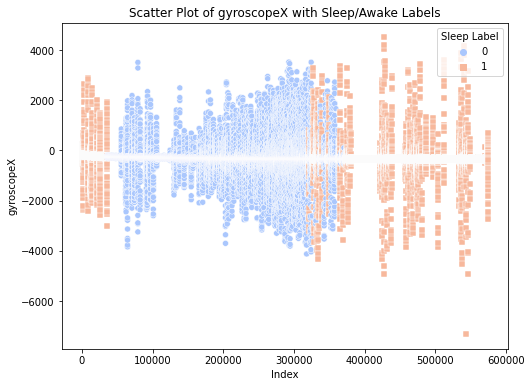

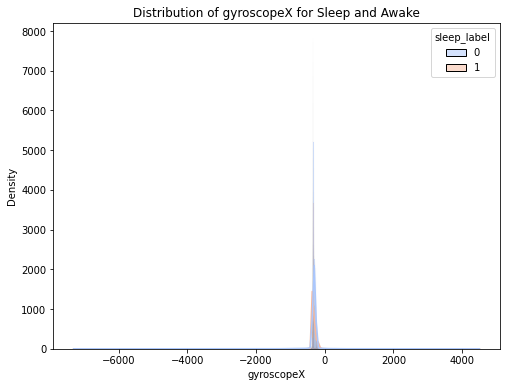

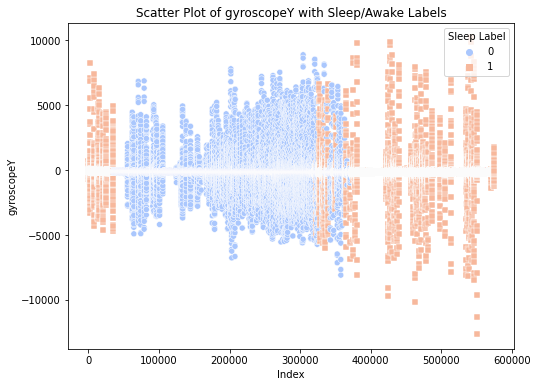

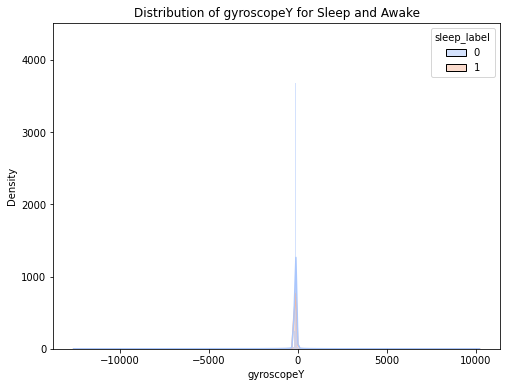

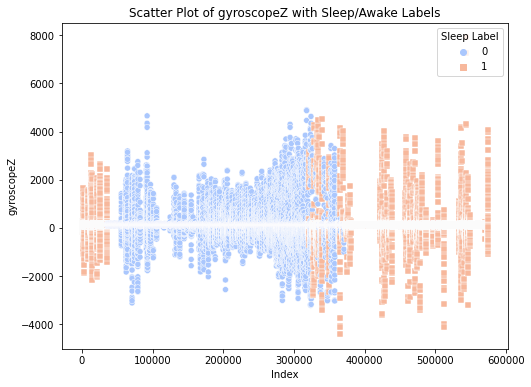

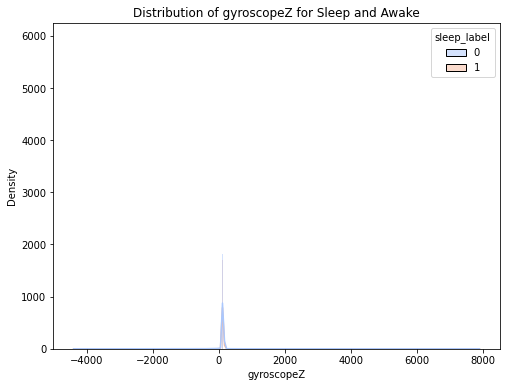

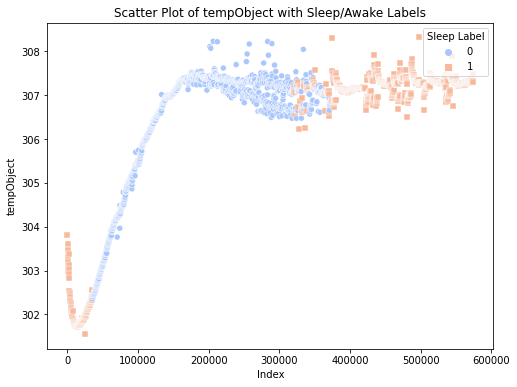

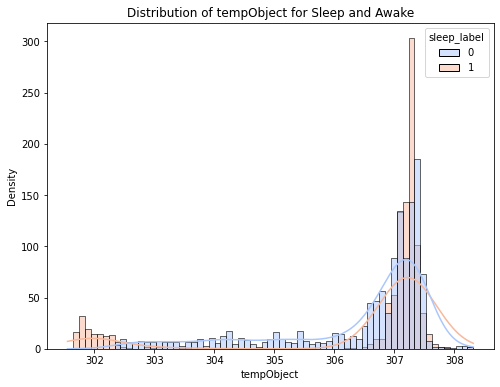

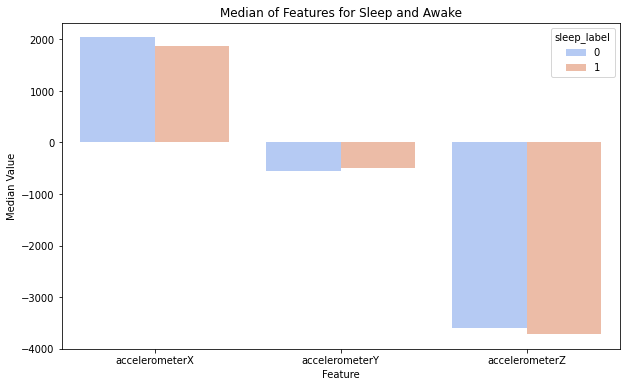

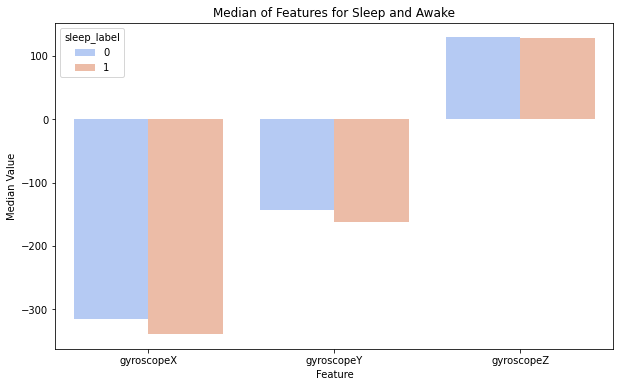

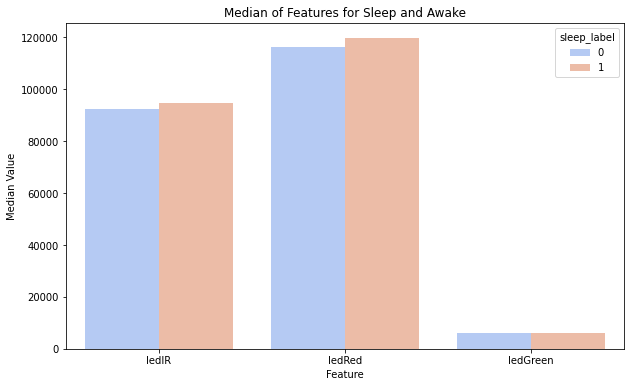

In [3]:
folder_path = '/home/yanwar/Desktop/Sleep/data/train/'
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        # Apply sleep/awake labels
        df['sleep_label'] = df['sleep_stage'].apply(lambda x: 0 if x == 'WK' else 1)  # 0: awake, 1: sleep
        
        PPG_df = df.dropna(subset=['ledIR', 'ledRed', 'ledGreen', 'sleep_label'])
        acc_df = df.dropna(subset=['accelerometerX', 'accelerometerY', 'accelerometerZ', 'sleep_label'])
        gyro_df = df.dropna(subset=['gyroscopeX', 'gyroscopeY', 'gyroscopeZ', 'sleep_label'])
        temp_df = df.dropna(subset=['tempObject', 'sleep_label'])
        
        # PPG Scatter and Distribution Plots
        for feature in ['ledIR', 'ledRed', 'ledGreen']:
            create_scatter_plot(PPG_df, feature, f'plots/scatter/{filename}_scatter_{feature}.png')
            create_distribution_plot(PPG_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')

#         # Accelerometer Scatter and Distribution Plots
        for feature in ['accelerometerX', 'accelerometerY', 'accelerometerZ']:
            create_scatter_plot(acc_df, feature, f'plots/scatter/{filename}_scatter_{feature}.png')
            create_distribution_plot(acc_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')

#         # Gyroscope Scatter and Distribution Plots
        for feature in ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']:
            create_scatter_plot(gyro_df, feature, f'plots/scatter/{filename}_scatter_{feature}.png')
            create_distribution_plot(gyro_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')

#         # Temperature Scatter and Distribution Plots
        create_scatter_plot(temp_df, 'tempObject', f'plots/scatter/{filename}_scatter_tempObject.png')
        create_distribution_plot(temp_df, 'tempObject', f'plots/distribution/{filename}_dist_tempObject.png')

#         # Bar Plot of Medians for Accelerometer, Gyroscope, and PPG
        create_median_bar_plot(acc_df, ['accelerometerX', 'accelerometerY', 'accelerometerZ'], f'plots/median_bar/{filename}_acc_median_bar.png')
        create_median_bar_plot(gyro_df, ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ'], f'plots/median_bar/{filename}_gyro_median_bar.png')
        create_median_bar_plot(PPG_df, ['ledIR', 'ledRed', 'ledGreen'], f'plots/median_bar/{filename}_ppg_median_bar.png')
        
        
        
        
        break

/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app
/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/ipykernel_launcher.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/ipykernel_launcher.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


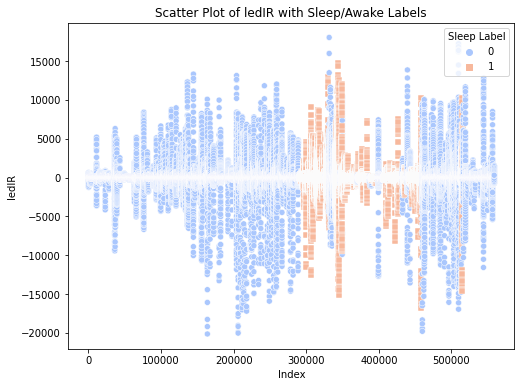

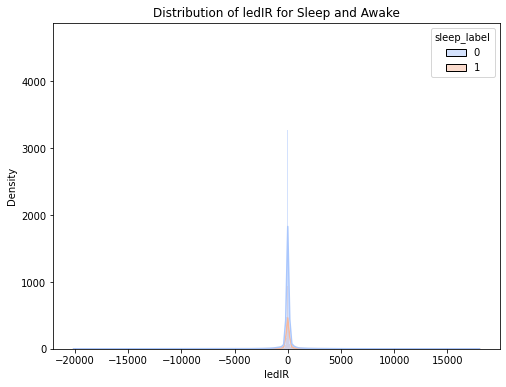

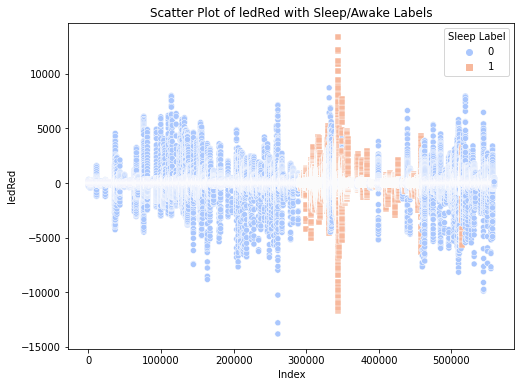

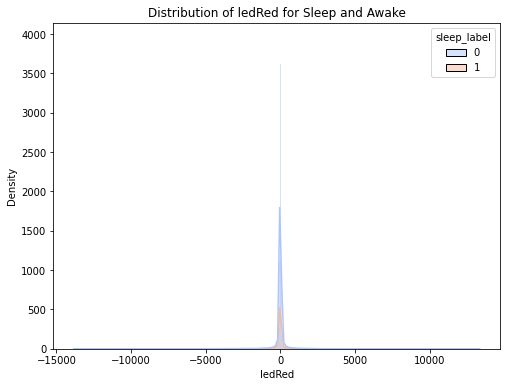

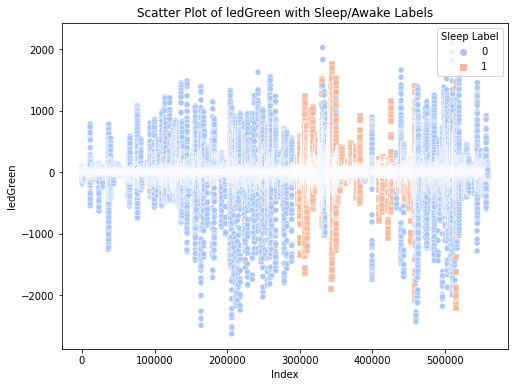

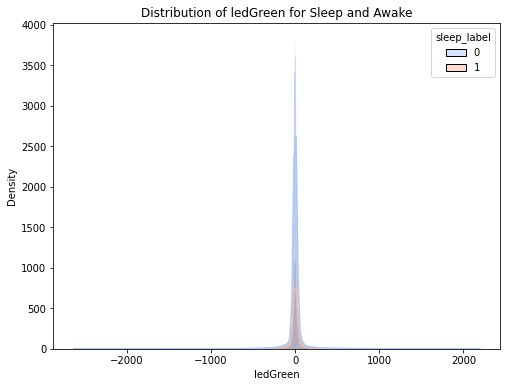

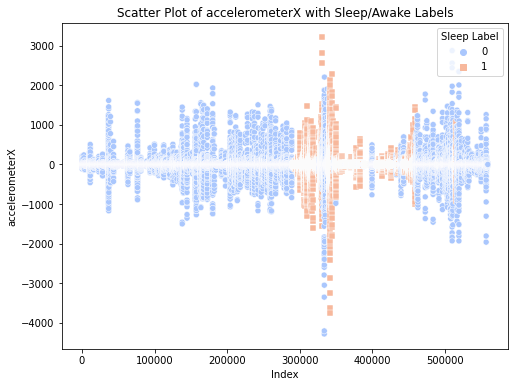

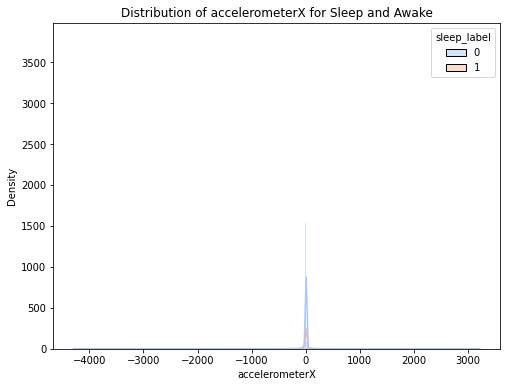

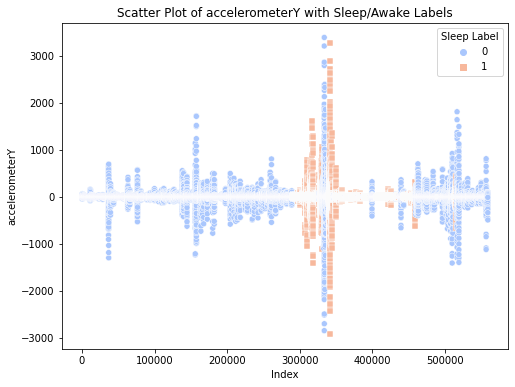

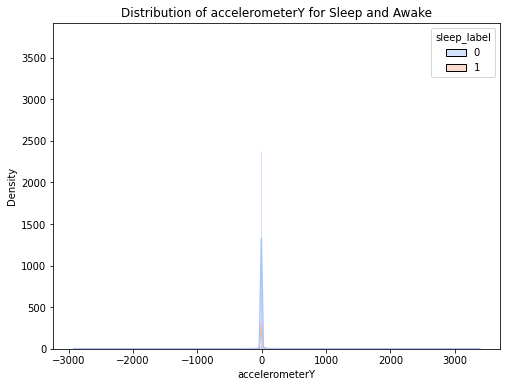

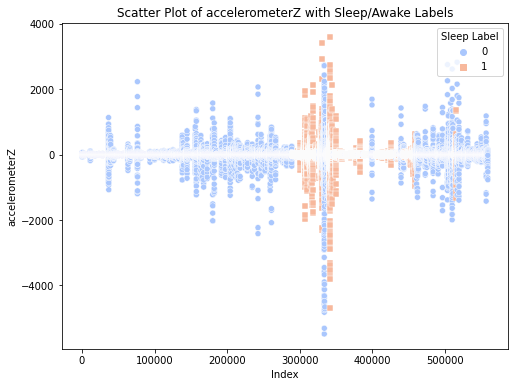

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f7987e87ef0> (for post_execute):


KeyboardInterrupt: 

In [6]:
folder_path = '/home/yanwar/Desktop/Sleep/data/train/'
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        # Apply sleep/awake labels
        df['sleep_label'] = df['sleep_stage'].apply(lambda x: 0 if x == 'WK' else 1)  # 0: awake, 1: sleep
        
        PPG_df = df.dropna(subset=['ledIR', 'ledRed', 'ledGreen', 'sleep_label'])
        acc_df = df.dropna(subset=['accelerometerX', 'accelerometerY', 'accelerometerZ', 'sleep_label'])
        gyro_df = df.dropna(subset=['gyroscopeX', 'gyroscopeY', 'gyroscopeZ', 'sleep_label'])
        temp_df = df.dropna(subset=['tempObject', 'sleep_label'])
        
        for feature in ['ledIR', 'ledRed', 'ledGreen']:
            PPG_df[feature] = bandpass_filter(PPG_df[feature], 0.2, 5, 25)
        for feature in ['accelerometerX', 'accelerometerY', 'accelerometerZ']:
            acc_df[feature] = bandpass_filter(acc_df[feature], 0.5, 5, 25)
        for feature in ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']:
            gyro_df[feature] = bandpass_filter(gyro_df[feature], 0.5, 5, 25)
        
        # PPG Scatter and Distribution Plots
        for feature in ['ledIR', 'ledRed', 'ledGreen']:
            create_scatter_plot(PPG_df, feature, f'plots/scatter/{filename}_scatter_{feature}.png')
            create_distribution_plot(PPG_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')

#         # Accelerometer Scatter and Distribution Plots
        for feature in ['accelerometerX', 'accelerometerY', 'accelerometerZ']:
            create_scatter_plot(acc_df, feature, f'plots/scatter/{filename}_scatter_{feature}.png')
            create_distribution_plot(acc_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')

#         # Gyroscope Scatter and Distribution Plots
        for feature in ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']:
            create_scatter_plot(gyro_df, feature, f'plots/scatter/{filename}_scatter_{feature}.png')
            create_distribution_plot(gyro_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')

#         # Temperature Scatter and Distribution Plots
        create_scatter_plot(temp_df, 'tempObject', f'plots/scatter/{filename}_scatter_tempObject.png')
        create_distribution_plot(temp_df, 'tempObject', f'plots/distribution/{filename}_dist_tempObject.png')

#         # Bar Plot of Medians for Accelerometer, Gyroscope, and PPG
        create_median_bar_plot(acc_df, ['accelerometerX', 'accelerometerY', 'accelerometerZ'], f'plots/median_bar/{filename}_acc_median_bar.png')
        create_median_bar_plot(gyro_df, ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ'], f'plots/median_bar/{filename}_gyro_median_bar.png')
        create_median_bar_plot(PPG_df, ['ledIR', 'ledRed', 'ledGreen'], f'plots/median_bar/{filename}_ppg_median_bar.png')
        
        
        
        
        break

In [6]:
def create_mean_median_bar_plot_with_error(df, feature_list, save_path):
    """
    Create a bar plot of medians and means with error bars for a list of features.
    
    Args:
    df (pd.DataFrame): The DataFrame containing the sensor data.
    feature_list (list): A list of feature columns to plot.
    save_path (str): The file path to save the plot.
    """
    # Calculate mean, median, and IQR (25th and 75th percentiles) for each feature and sleep label
    summary_df = df.groupby('sleep_label').agg(
        **{f'{feature}_Mean': pd.NamedAgg(column=feature, aggfunc='mean') for feature in feature_list},
        **{f'{feature}_Median': pd.NamedAgg(column=feature, aggfunc='median') for feature in feature_list},
        **{f'{feature}_Q1': pd.NamedAgg(column=feature, aggfunc=lambda x: x.quantile(0.25)) for feature in feature_list},
        **{f'{feature}_Q3': pd.NamedAgg(column=feature, aggfunc=lambda x: x.quantile(0.75)) for feature in feature_list}
    ).reset_index()

    # Reshape the dataframe for plotting
    melted_mean = summary_df.melt(id_vars='sleep_label', value_vars=[f'{feature}_Mean' for feature in feature_list], var_name='Feature', value_name='Mean')
    melted_median = summary_df.melt(id_vars='sleep_label', value_vars=[f'{feature}_Median' for feature in feature_list], var_name='Feature', value_name='Median')
    melted_q1 = summary_df.melt(id_vars='sleep_label', value_vars=[f'{feature}_Q1' for feature in feature_list], var_name='Feature', value_name='Q1')
    melted_q3 = summary_df.melt(id_vars='sleep_label', value_vars=[f'{feature}_Q3' for feature in feature_list], var_name='Feature', value_name='Q3')

    # Combine the melted dataframes to get Q1 and Q3 values for error bars
    combined_df = melted_mean.copy()
    combined_df['Median'] = melted_median['Median']
    combined_df['Q1'] = melted_q1['Q1']
    combined_df['Q3'] = melted_q3['Q3']
    
    # Calculate IQR (Interquartile Range) as Q3 - Q1
    combined_df['IQR'] = combined_df['Q3'] - combined_df['Q1']

    # Plot the barplot with error bars for mean and median
    plt.figure(figsize=(12, 6))
    
    # Plot Mean
    mean_plot = sns.barplot(
        x='Feature', 
        y='Mean', 
        hue='sleep_label', 
        data=combined_df, 
        palette='coolwarm',
        ci=None
    )

    # Plot Median as a separate overlay with alpha
    median_plot = sns.barplot(
        x='Feature', 
        y='Median', 
        hue='sleep_label', 
        data=combined_df, 
        palette='dark', 
        ci=None,
        alpha=0.6
    )

    # Add error bars for the Mean (IQR/2 on each side as a basic error range)
    for i in range(combined_df.shape[0]):
        plt.errorbar(
            x=i % len(feature_list),  # Adjust the x-axis index
            y=combined_df['Mean'][i],
            yerr=combined_df['IQR'][i] / 2,
            fmt='none',  # No marker for the error bars
            capsize=5,  # Add caps to the error bars
            color='black'  # Error bars color
        )

    # Fix the legend to avoid duplication
    handles, labels = mean_plot.get_legend_handles_labels()
    mean_plot.legend(handles[:2], ['Sleep', 'Awake'], title='Sleep Label')

    plt.title(f'Mean and Median of Features for Sleep and Awake with Error Bars')
    plt.xlabel('Feature')
    plt.ylabel('Value')
    plt.tight_layout()
    #plt.savefig(save_path)
    plt.show()


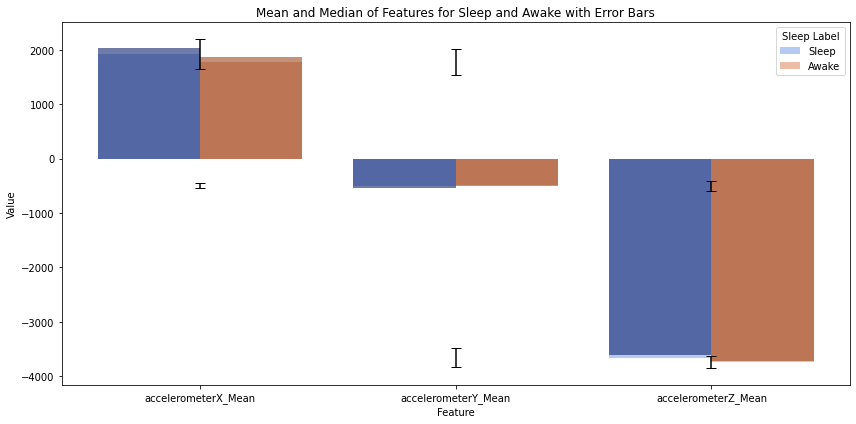

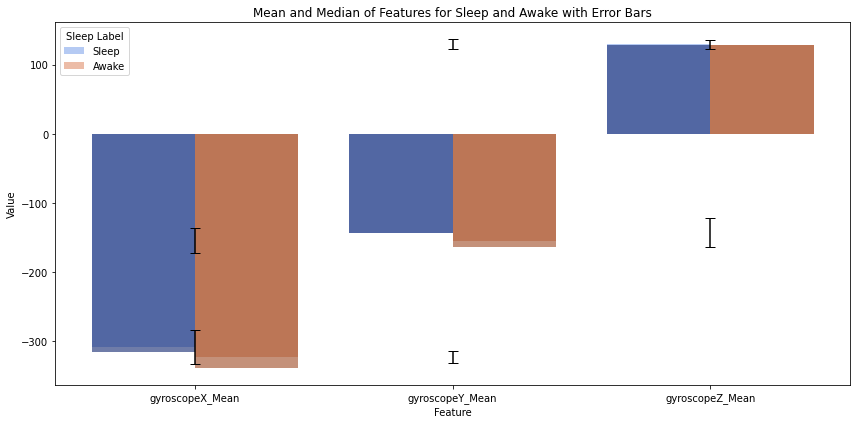

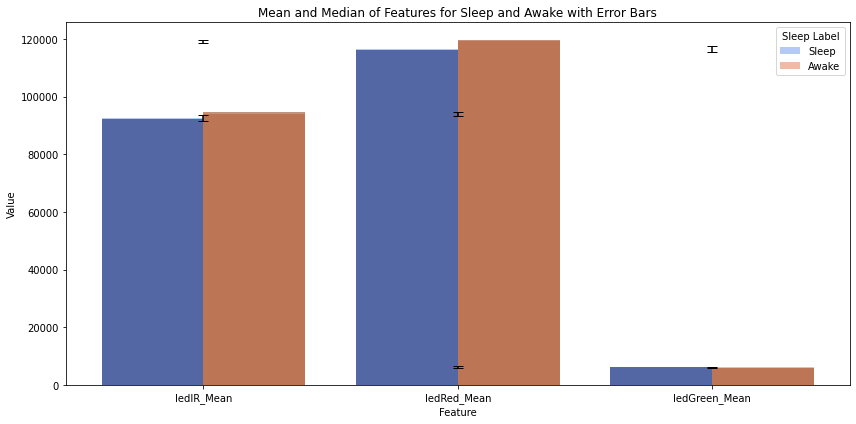

In [7]:
folder_path = '/home/yanwar/Desktop/Sleep/data/test/'
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        # Apply sleep/awake labels
        df['sleep_label'] = df['sleep_stage'].apply(lambda x: 0 if x == 'WK' else 1)  # 0: awake, 1: sleep
        
        PPG_df = df.dropna(subset=['ledIR', 'ledRed', 'ledGreen', 'sleep_label'])
        acc_df = df.dropna(subset=['accelerometerX', 'accelerometerY', 'accelerometerZ', 'sleep_label'])
        gyro_df = df.dropna(subset=['gyroscopeX', 'gyroscopeY', 'gyroscopeZ', 'sleep_label'])
        temp_df = df.dropna(subset=['tempObject', 'sleep_label'])
        
  
        # Bar Plot of Medians for Accelerometer, Gyroscope, and PPG
        create_mean_median_bar_plot_with_error(acc_df, ['accelerometerX', 'accelerometerY', 'accelerometerZ'], f'plots/median_bar/{filename}_acc_median_bar.png')
        create_mean_median_bar_plot_with_error(gyro_df, ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ'], f'plots/median_bar/{filename}_gyro_median_bar.png')
        create_mean_median_bar_plot_with_error(PPG_df, ['ledIR', 'ledRed', 'ledGreen'], f'plots/median_bar/{filename}_ppg_median_bar.png')
        
        
        
        
        break

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def create_box_plot_with_sleep_label(df, feature_list, save_path):
    """
    Create box plots for a list of features grouped by sleep/awake labels.

    Args:
    df (pd.DataFrame): DataFrame containing the features and the sleep label.
    feature_list (list): A list of feature columns to plot.
    save_path (str): The file path to save the plot.
    """
    for feature in feature_list:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='sleep_label', y=feature, data=df, palette='coolwarm')
        plt.title(f'Box Plot of {feature} by Sleep/Awake')
        plt.xticks([0, 1], ['Awake', 'Sleep'])
        plt.ylabel(f'{feature} Value')
        plt.xlabel('Sleep Label')
        #plt.savefig(f'{save_path}/{feature}_boxplot_sleep.png')
        plt.show()

def create_box_plot_before_after_scaling(df, scaled_df, feature_list, save_path):
    """
    Create box plots comparing before and after scaling for sleep/awake labels.

    Args:
    df (pd.DataFrame): DataFrame containing features before scaling.
    scaled_df (pd.DataFrame): DataFrame containing features after scaling.
    feature_list (list): List of feature names to plot.
    save_path (str): Directory to save the plots.
    """
    for feature in feature_list:
        plt.figure(figsize=(12, 6))
        
        # Before scaling
        plt.subplot(1, 2, 1)
        sns.boxplot(x='sleep_label', y=feature, data=df, palette='coolwarm')
        plt.title(f'{feature} Before Scaling by Sleep/Awake')
        plt.xticks([0, 1], ['Awake', 'Sleep'])
        plt.ylabel(f'{feature} Value')
        
        # After scaling
        plt.subplot(1, 2, 2)
        sns.boxplot(x='sleep_label', y=feature, data=scaled_df, palette='coolwarm')
        plt.title(f'{feature} After Scaling by Sleep/Awake')
        plt.xticks([0, 1], ['Awake', 'Sleep'])
        plt.ylabel(f'{feature} Value')
        
        plt.tight_layout()
        #plt.savefig(f'{save_path}/{feature}_boxplot_before_after_scaling.png')
        plt.show()


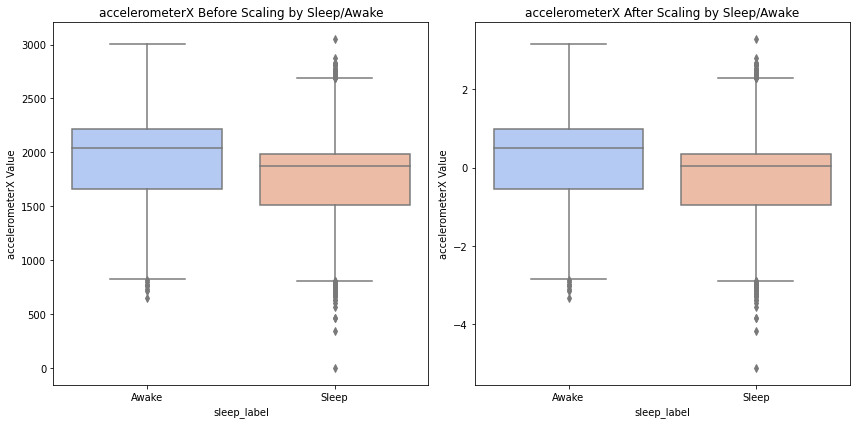

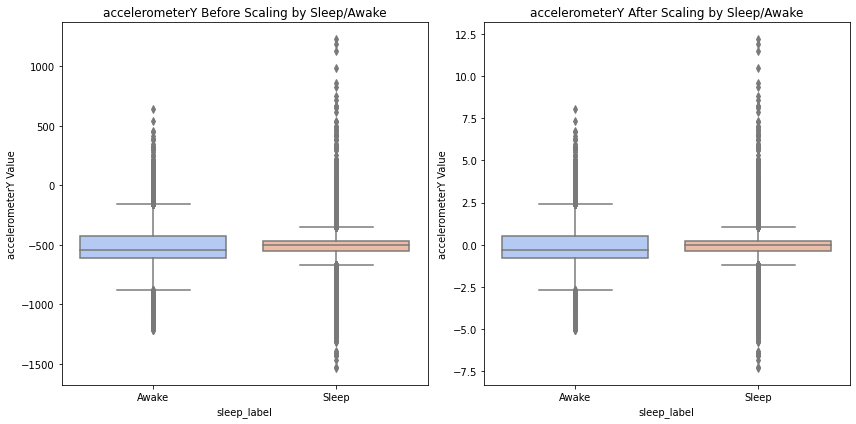

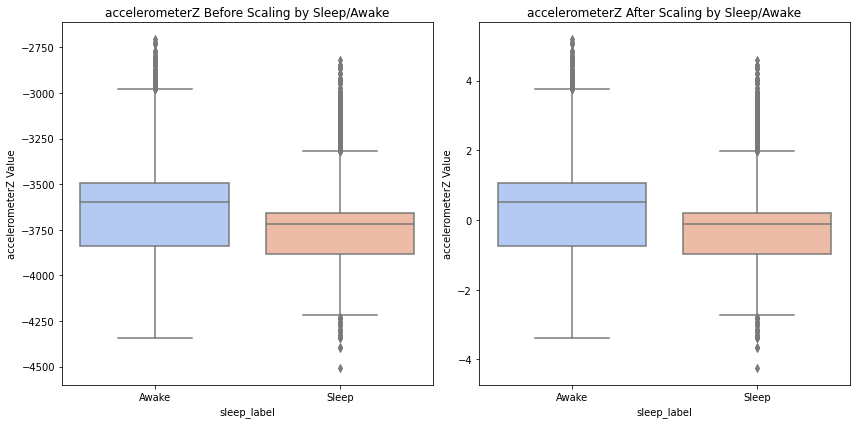

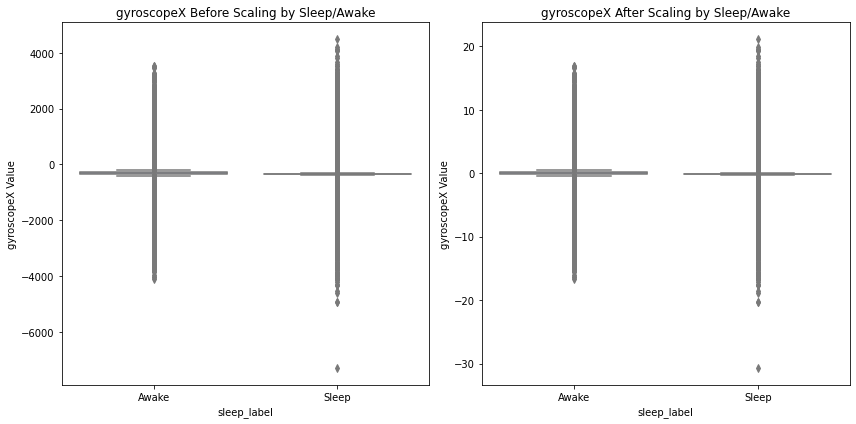

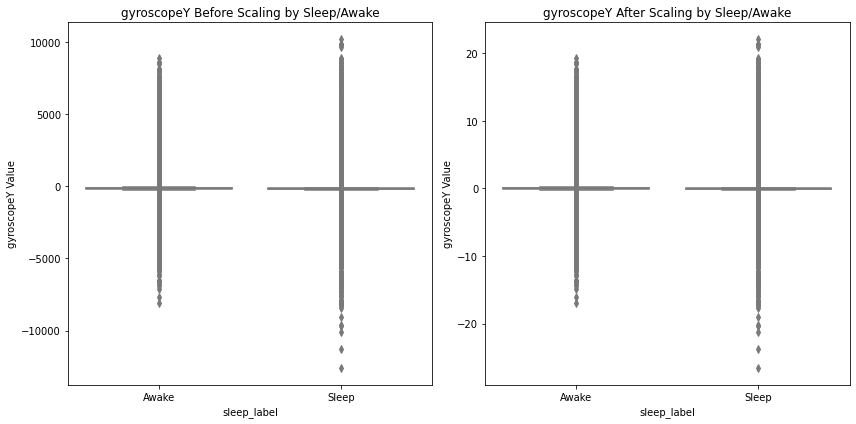

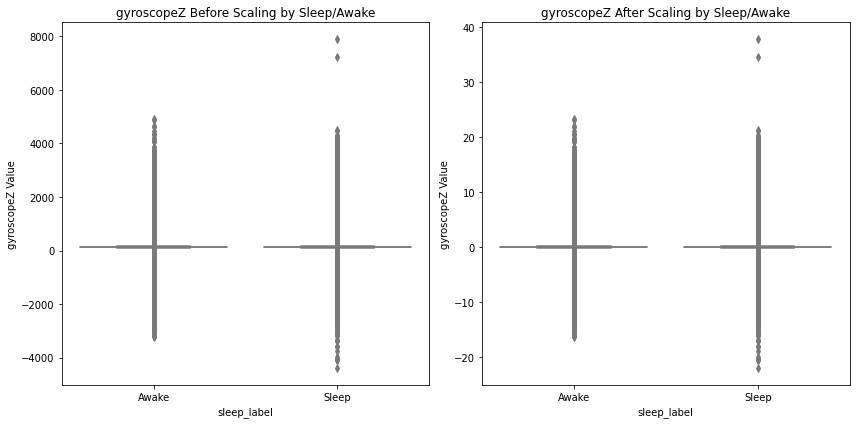

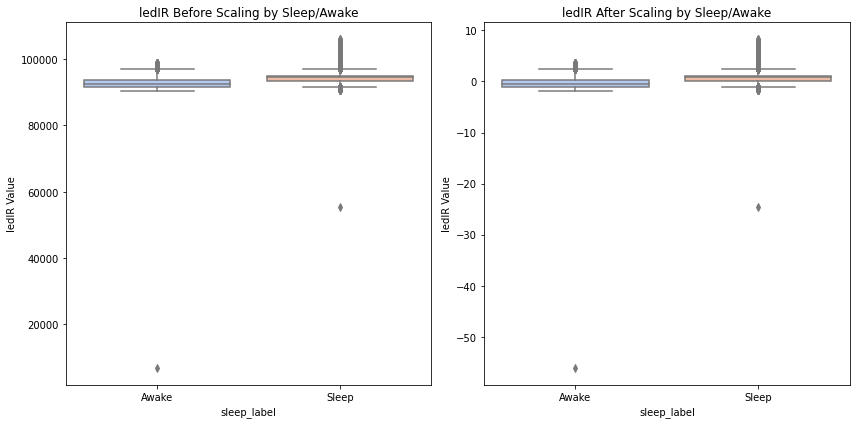

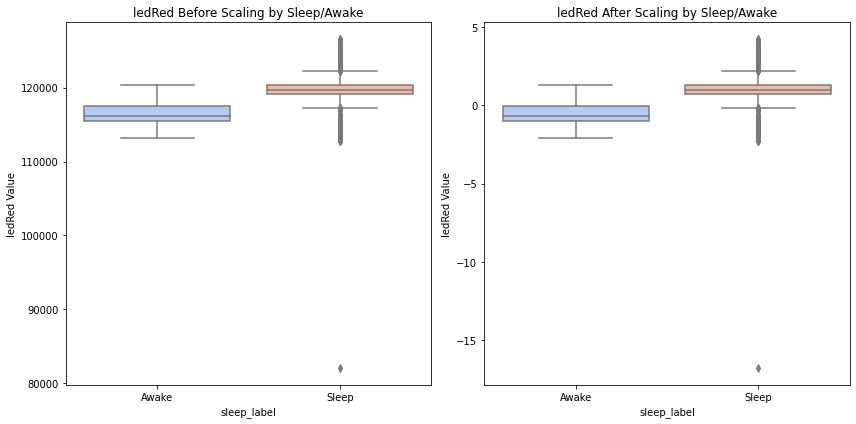

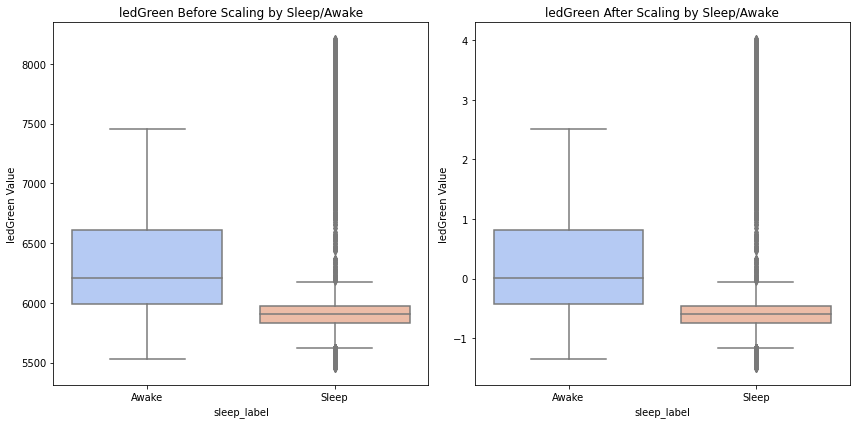

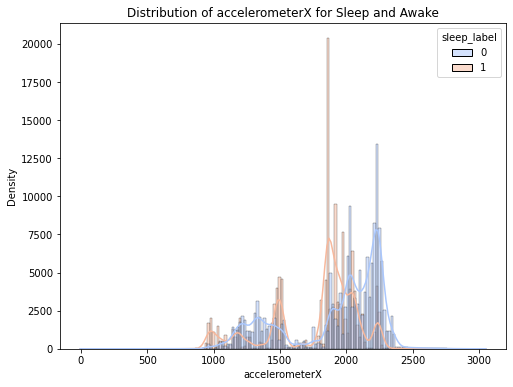

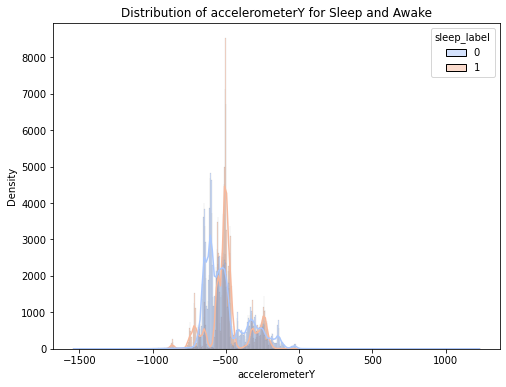

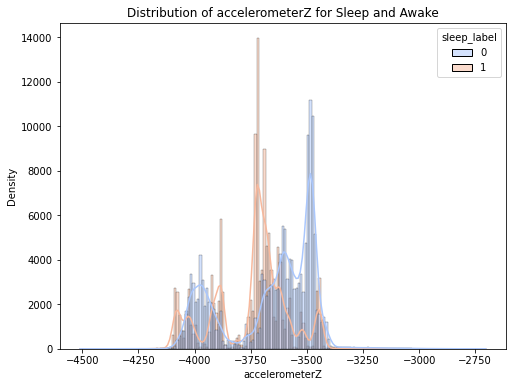

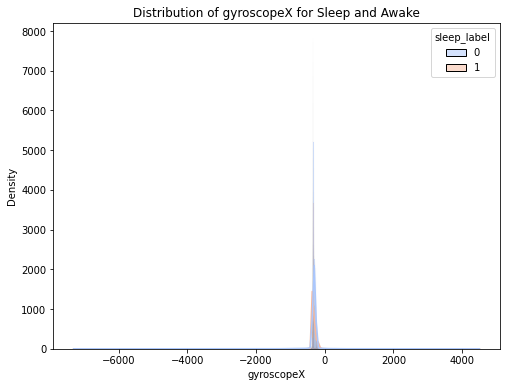

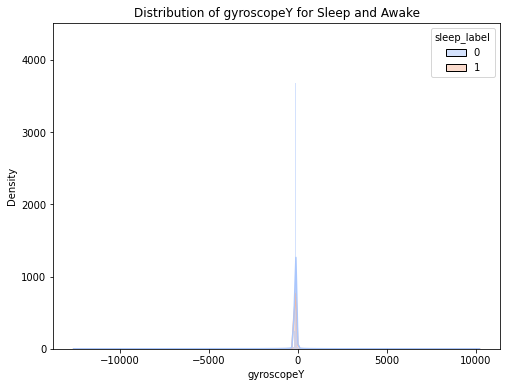

KeyboardInterrupt: 

In [14]:
folder_path = '/home/yanwar/Desktop/Sleep/data/test/'
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        # Apply sleep/awake labels
        df['sleep_label'] = df['sleep_stage'].apply(lambda x: 0 if x == 'WK' else 1)  # 0: awake, 1: sleep
        
        # Separate dataframes
        PPG_df = df.dropna(subset=['ledIR', 'ledRed', 'ledGreen', 'sleep_label'])
        acc_df = df.dropna(subset=['accelerometerX', 'accelerometerY', 'accelerometerZ', 'sleep_label'])
        gyro_df = df.dropna(subset=['gyroscopeX', 'gyroscopeY', 'gyroscopeZ', 'sleep_label'])
        
        # Standardize data
        scaler = StandardScaler()
        acc_df_scaled = acc_df.copy()
        gyro_df_scaled = gyro_df.copy()
        PPG_df_scaled = PPG_df.copy()
        
        acc_df_scaled[['accelerometerX', 'accelerometerY', 'accelerometerZ']] = scaler.fit_transform(acc_df[['accelerometerX', 'accelerometerY', 'accelerometerZ']])
        gyro_df_scaled[['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']] = scaler.fit_transform(gyro_df[['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']])
        PPG_df_scaled[['ledIR', 'ledRed', 'ledGreen']] = scaler.fit_transform(PPG_df[['ledIR', 'ledRed', 'ledGreen']])
        
        # Create box plots for sleep/awake comparison before and after scaling
        create_box_plot_before_after_scaling(acc_df, acc_df_scaled, ['accelerometerX', 'accelerometerY', 'accelerometerZ'], f'plots/boxplot/{filename}_acc_boxplot.png')
        create_box_plot_before_after_scaling(gyro_df, gyro_df_scaled, ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ'], f'plots/boxplot/{filename}_gyro_boxplot.png')
        create_box_plot_before_after_scaling(PPG_df, PPG_df_scaled, ['ledIR', 'ledRed', 'ledGreen'], f'plots/boxplot/{filename}_ppg_boxplot.png')
        
        for feature in ['accelerometerX', 'accelerometerY', 'accelerometerZ']:
            create_distribution_plot(acc_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')
        for feature in ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']:
            create_distribution_plot(gyro_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')
        

        break


/home/yanwar/anaconda3/envs/test_GPU_clone/lib/python3.7/site-packages/ipykernel_launcher.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app.launch_new_instance()


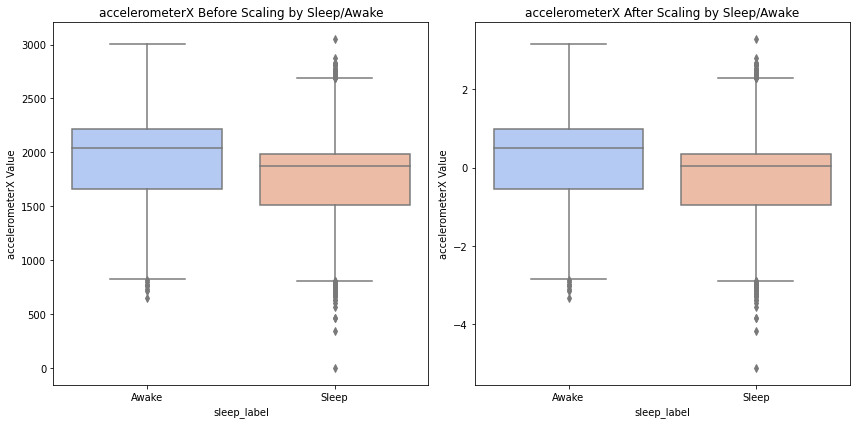

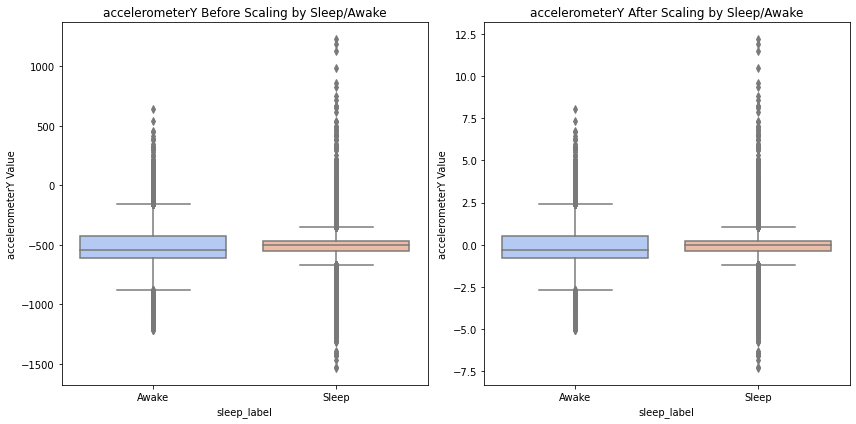

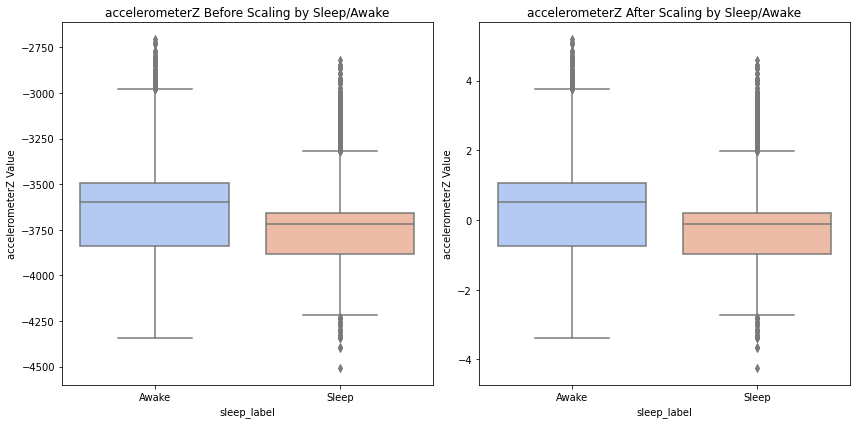

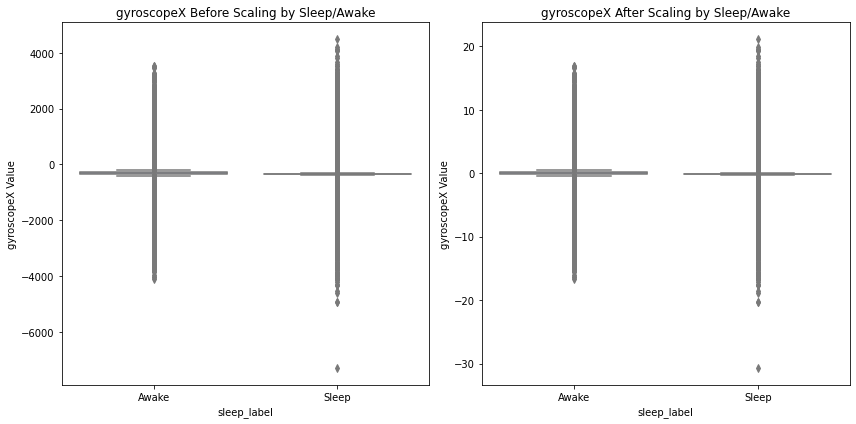

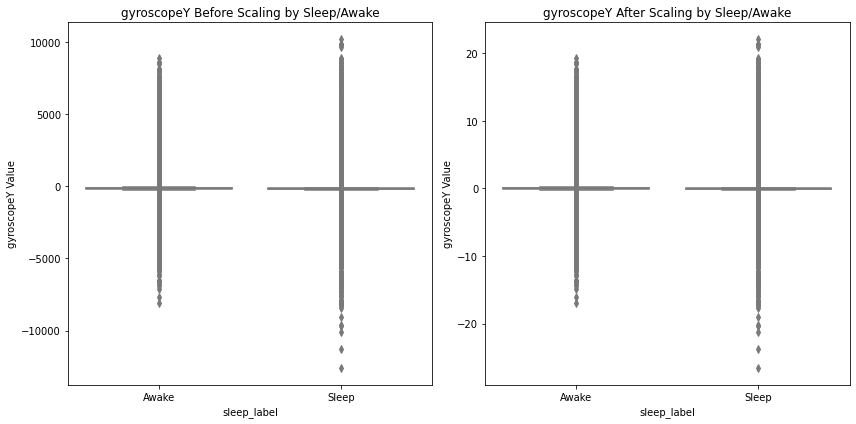

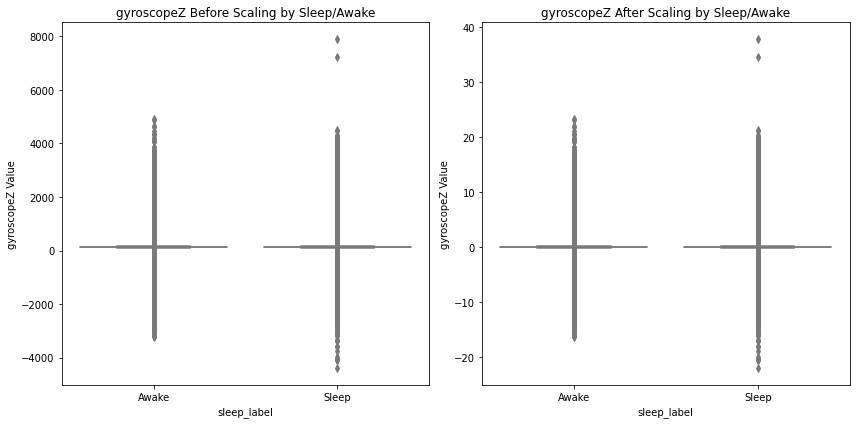

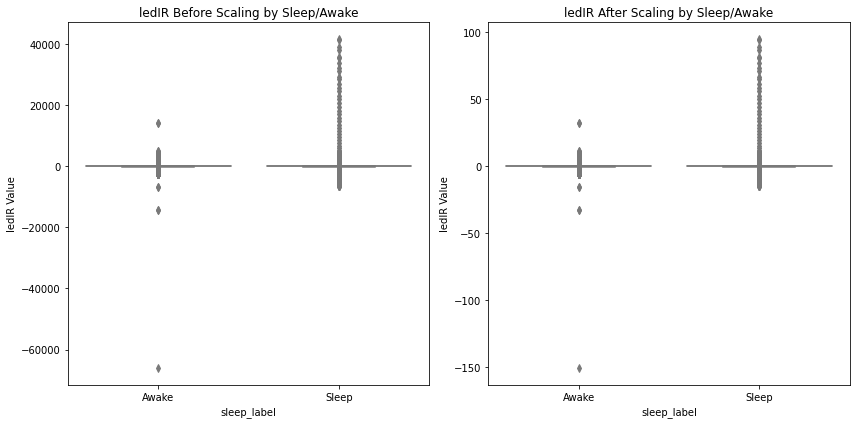

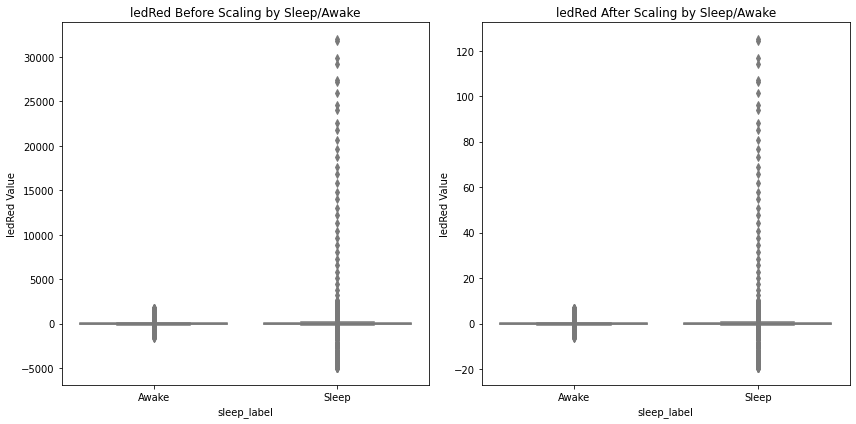

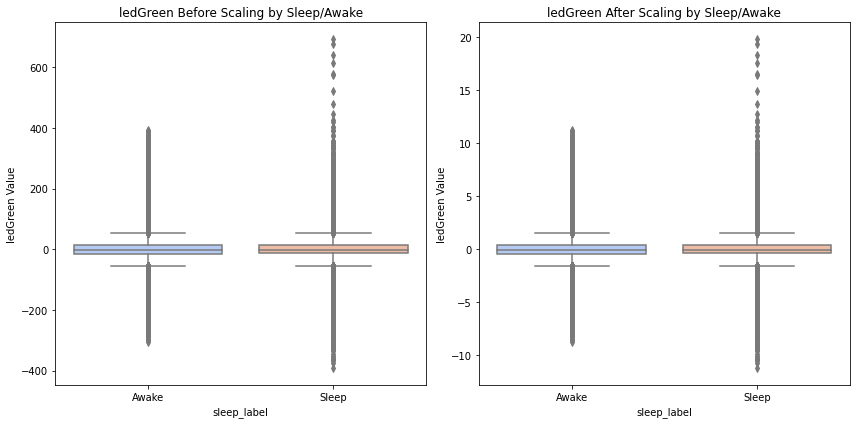

In [20]:
folder_path = '/home/yanwar/Desktop/Sleep/data/test/'
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        # Apply sleep/awake labels
        df['sleep_label'] = df['sleep_stage'].apply(lambda x: 0 if x == 'WK' else 1)  # 0: awake, 1: sleep
        
        # Separate dataframes
        PPG_df = df.dropna(subset=['ledIR', 'ledRed', 'ledGreen', 'sleep_label'])
        acc_df = df.dropna(subset=['accelerometerX', 'accelerometerY', 'accelerometerZ', 'sleep_label'])
        gyro_df = df.dropna(subset=['gyroscopeX', 'gyroscopeY', 'gyroscopeZ', 'sleep_label'])
        
        
        for feature in ['ledIR', 'ledRed', 'ledGreen']:
            PPG_df[feature] = bandpass_filter(PPG_df[feature], 0.2, 10, 25)
#         for feature in ['accelerometerX', 'accelerometerY', 'accelerometerZ']:
#             acc_df[feature] = bandpass_filter(acc_df[feature], 0.2, 12.5, 25)
#         for feature in ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']:
#             gyro_df[feature] = bandpass_filter(gyro_df[feature], 0.2, 12.5, 25)
            
            
        
        # Standardize data
        scaler = StandardScaler()
        acc_df_scaled = acc_df.copy()
        gyro_df_scaled = gyro_df.copy()
        PPG_df_scaled = PPG_df.copy()
        
        acc_df_scaled[['accelerometerX', 'accelerometerY', 'accelerometerZ']] = scaler.fit_transform(acc_df[['accelerometerX', 'accelerometerY', 'accelerometerZ']])
        gyro_df_scaled[['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']] = scaler.fit_transform(gyro_df[['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']])
        PPG_df_scaled[['ledIR', 'ledRed', 'ledGreen']] = scaler.fit_transform(PPG_df[['ledIR', 'ledRed', 'ledGreen']])
        
        # Create box plots for sleep/awake comparison before and after scaling
        create_box_plot_before_after_scaling(acc_df, acc_df_scaled, ['accelerometerX', 'accelerometerY', 'accelerometerZ'], f'plots/boxplot/{filename}_acc_boxplot.png')
        create_box_plot_before_after_scaling(gyro_df, gyro_df_scaled, ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ'], f'plots/boxplot/{filename}_gyro_boxplot.png')
        create_box_plot_before_after_scaling(PPG_df, PPG_df_scaled, ['ledIR', 'ledRed', 'ledGreen'], f'plots/boxplot/{filename}_ppg_boxplot.png')
        
#         for feature in ['accelerometerX', 'accelerometerY', 'accelerometerZ']:
#             create_distribution_plot(acc_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')
#         for feature in ['gyroscopeX', 'gyroscopeY', 'gyroscopeZ']:
#             create_distribution_plot(gyro_df, feature, f'plots/distribution/{filename}_dist_{feature}.png')
        
        
        break
